# Exploratory Data Analysis — PlantVillage Tomato Subset

**Goal:** understand the data *before* building a model. Specifically:

1. **How much data is there, and how is it split across classes?**
   A model trained on a lopsided dataset can score high accuracy simply by
   favouring the biggest class, so we need to know the balance up front.
2. **What do the images actually look like?**
   Eyeballing samples catches problems no summary statistic will — wrong
   labels, inconsistent backgrounds, images that are not leaves at all.
3. **What size are the images?**
   The CNN needs one fixed input size. This tells us what we are resizing
   *from*, and whether resizing will distort anything.
4. **Are any files corrupt?**
   One unreadable JPEG will crash a training run partway through. Better to
   find them now than 40 minutes into training.

Every finding here feeds a concrete decision in Phase 3 (preprocessing) and
Phase 4 (model design).

In [1]:
# --- Imports ---------------------------------------------------------------
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Consistent, readable plot styling for the whole notebook.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- Paths -----------------------------------------------------------------
# The notebook lives in notebooks/, so the project root is one level up.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "tomato"

# Figures are saved here so the README can embed them later.
FIGURES_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data folder :", DATA_DIR)
print("Data exists :", DATA_DIR.exists())

Project root: M:\CROP-DISEASE-DETECTION
Data folder : M:\CROP-DISEASE-DETECTION\data\raw\tomato
Data exists : True


## 1. Inventory the dataset

The images are stored one folder per class:

```
data/raw/tomato/
├── Tomato___Bacterial_spot/
├── Tomato___Early_blight/
└── ...
```

This "folder name = label" convention is worth keeping, because Keras'
`image_dataset_from_directory` reads exactly this layout in Phase 3 — no
separate CSV of labels needed.

We walk the tree once and build a small DataFrame with one row per image.

In [2]:
# Every class is a subfolder; every image inside it carries that label.
records = []
for class_dir in sorted(p for p in DATA_DIR.iterdir() if p.is_dir()):
    for image_path in class_dir.iterdir():
        if image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "path": image_path,
                # Strip the "Tomato___" prefix -- it is on every class and
                # only makes the plot labels harder to read.
                "label": class_dir.name.replace("Tomato___", ""),
            })

df = pd.DataFrame(records)

print(f"Total images : {len(df):,}")
print(f"Total classes: {df['label'].nunique()}")
df.head()

Total images : 18,160
Total classes: 10


,path,label
0,M:\CROP-DISEASE-DETECTION\data\raw\tomato\Toma...,Bacterial_spot
1,M:\CROP-DISEASE-DETECTION\data\raw\tomato\Toma...,Bacterial_spot
2,M:\CROP-DISEASE-DETECTION\data\raw\tomato\Toma...,Bacterial_spot
3,M:\CROP-DISEASE-DETECTION\data\raw\tomato\Toma...,Bacterial_spot
4,M:\CROP-DISEASE-DETECTION\data\raw\tomato\Toma...,Bacterial_spot


### Images per class

In [3]:
# value_counts() gives the per-class totals, sorted largest first.
class_counts = df["label"].value_counts()

# Present it as a table with each class's share of the dataset, which makes
# imbalance easier to read than raw counts alone.
counts_table = pd.DataFrame({
    "images": class_counts,
    "share_%": (class_counts / len(df) * 100).round(1),
})
counts_table

,images,share_%
label,,
Tomato_Yellow_Leaf_Curl_Virus,5357,29.5
Bacterial_spot,2127,11.7
Late_blight,1909,10.5
Septoria_leaf_spot,1771,9.8
Spider_mites Two-spotted_spider_mite,1676,9.2
healthy,1591,8.8
Target_Spot,1404,7.7
Early_blight,1000,5.5
Leaf_Mold,952,5.2


In [4]:
# A single number that summarises how lopsided the dataset is.
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"Largest class : {class_counts.idxmax()} ({class_counts.max():,} images)")
print(f"Smallest class: {class_counts.idxmin()} ({class_counts.min():,} images)")
print(f"Imbalance ratio (largest / smallest): {imbalance_ratio:.1f}x")
print()
print(f"Baseline accuracy from always guessing the majority class: "
      f"{class_counts.max() / len(df):.1%}")

Largest class : Tomato_Yellow_Leaf_Curl_Virus (5,357 images)
Smallest class: Tomato_mosaic_virus (373 images)
Imbalance ratio (largest / smallest): 14.4x

Baseline accuracy from always guessing the majority class: 29.5%


**Why that last number matters.** A model that ignores the image entirely and
always predicts the most common class would score that "baseline" accuracy. Any
real model has to beat it convincingly, otherwise it has learned nothing about
leaves. This is the number to quote when someone asks "is 90% accuracy good?" —
it depends entirely on what guessing gets you.

## 2. Class distribution

A horizontal bar chart makes the long class names readable and the imbalance
obvious at a glance.

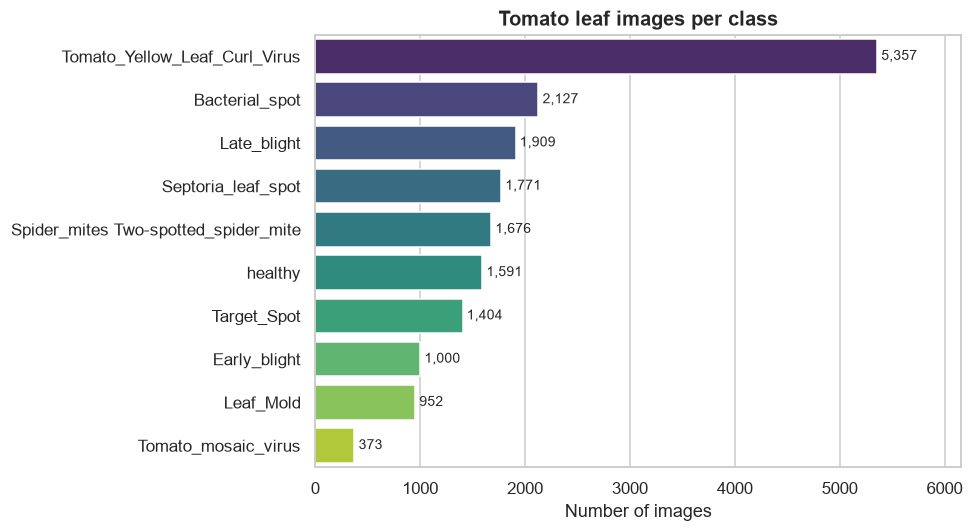

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

# Horizontal bars: the class names are long, so they read better on the y-axis.
sns.barplot(
    x=class_counts.values,
    y=class_counts.index,
    hue=class_counts.index,
    palette="viridis",
    legend=False,
    ax=ax,
)

# Print the exact count at the end of each bar -- a chart plus the real numbers
# is more useful than either alone.
for i, count in enumerate(class_counts.values):
    ax.text(count + 40, i, f"{count:,}", va="center", fontsize=9)

ax.set_title("Tomato leaf images per class", fontsize=13, weight="bold")
ax.set_xlabel("Number of images")
ax.set_ylabel("")
ax.set_xlim(0, class_counts.max() * 1.15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", bbox_inches="tight")
plt.show()

## 3. Sample images from each class

Summary statistics cannot tell us whether the labels make sense. Looking at a
handful of images per class is the cheapest quality check available — and it
also builds intuition for *why* the classification problem is hard.

Each row below is one class, with five random examples.

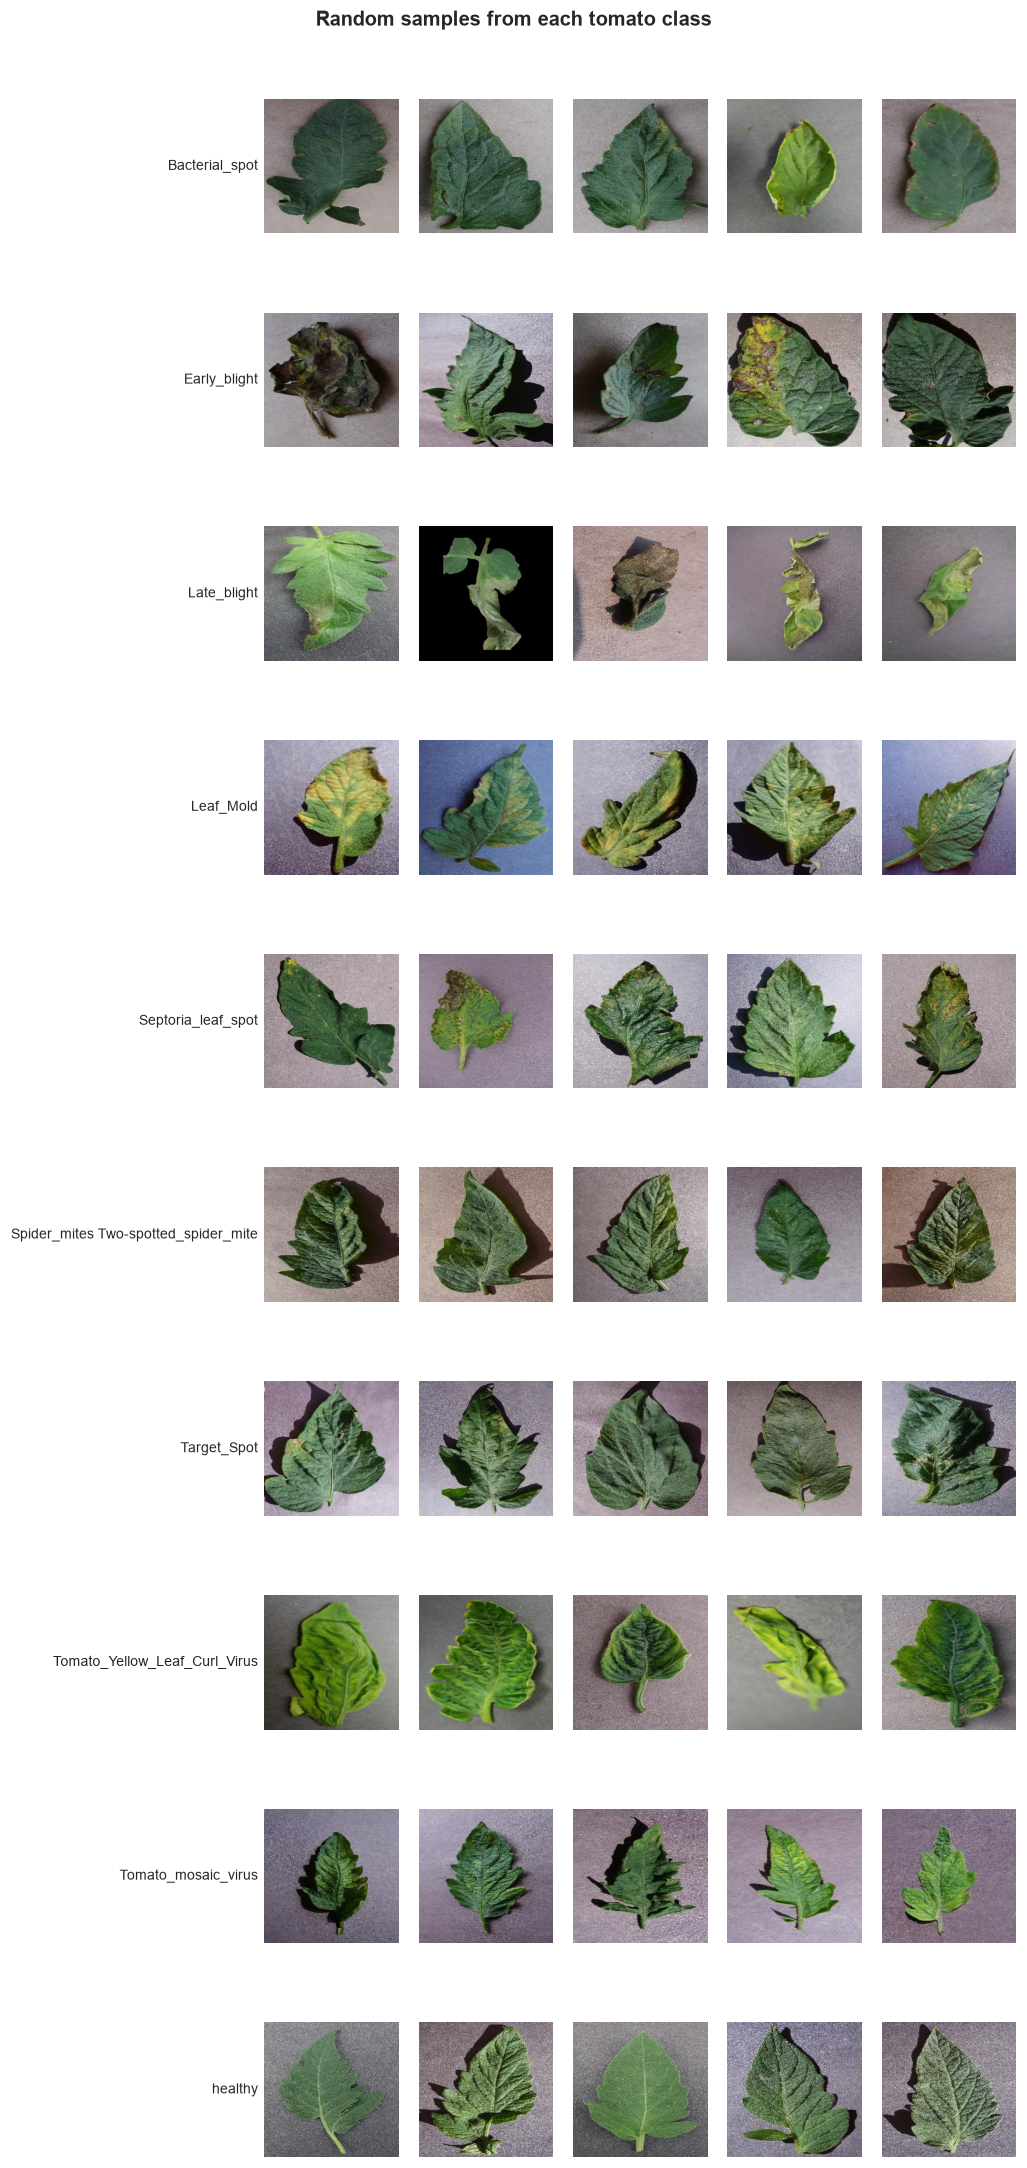

In [6]:
SAMPLES_PER_CLASS = 5
rng = np.random.default_rng(42)  # fixed seed -> the same grid every re-run

classes = sorted(df["label"].unique())
fig, axes = plt.subplots(
    len(classes), SAMPLES_PER_CLASS,
    figsize=(SAMPLES_PER_CLASS * 1.9, len(classes) * 2.0),
)

for row, label in enumerate(classes):
    paths = df.loc[df["label"] == label, "path"].to_numpy()
    picks = rng.choice(paths, size=SAMPLES_PER_CLASS, replace=False)

    for col, image_path in enumerate(picks):
        ax = axes[row, col]
        ax.imshow(Image.open(image_path))
        ax.axis("off")

    # Label the row once, on the left, instead of titling all five images.
    axes[row, 0].set_ylabel(label, rotation=0, ha="right", va="center", fontsize=9)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    for spine in axes[row, 0].spines.values():
        spine.set_visible(False)

fig.suptitle("Random samples from each tomato class", fontsize=13, weight="bold", y=0.999)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_images.png", bbox_inches="tight")
plt.show()

## 4. Image size and format

The CNN takes a fixed-size input, so every image gets resized in Phase 3. Before
choosing that size we need to know what we are starting from — and in
particular whether the images share an **aspect ratio**. Resizing a wide image
to a square stretches it; if all images are already square, that problem
disappears.

We read only each file's header here, not its pixels, so this pass is fast.

In [7]:
# Image.open() reads just the header, so .size and .mode are available
# without decoding the whole image -- fast even across ~18k files.
sizes, modes, formats = [], [], []

for image_path in df["path"]:
    with Image.open(image_path) as img:
        sizes.append(img.size)      # (width, height)
        modes.append(img.mode)      # e.g. "RGB"
        formats.append(img.format)  # e.g. "JPEG"

df["width"] = [w for w, _ in sizes]
df["height"] = [h for _, h in sizes]
df["mode"] = modes
df["format"] = formats

print("Resolutions found:")
print(df.groupby(["width", "height"]).size().rename("count").to_string())
print()
print("Colour modes:", Counter(modes))
print("File formats:", Counter(formats))

Resolutions found:
width  height
256    256       18160

Colour modes: Counter({'RGB': 18160})
File formats: Counter({'JPEG': 18160})


In [8]:
# Descriptive stats on the raw dimensions.
print(df[["width", "height"]].describe().round(1).to_string())
print()

square = (df["width"] == df["height"]).mean()
print(f"Square images: {square:.1%}")
print(f"Aspect ratios present: {sorted((df['width'] / df['height']).round(3).unique())}")

         width   height
count  18160.0  18160.0
mean     256.0    256.0
std        0.0      0.0
min      256.0    256.0
25%      256.0    256.0
50%      256.0    256.0
75%      256.0    256.0
max      256.0    256.0

Square images: 100.0%
Aspect ratios present: [np.float64(1.0)]


## 5. Corrupt or unreadable files

A truncated JPEG raises an exception the moment the data loader touches it,
which kills a training run mid-epoch. `PIL.Image.verify()` checks a file's
integrity without us having to decode and display it.

This pass reads every file in full, so it is slower than the header pass above.

In [9]:
corrupt = []

for image_path in df["path"]:
    try:
        with Image.open(image_path) as img:
            img.verify()  # raises on truncated / malformed files
    except Exception as exc:  # noqa: BLE001 -- we want to catch anything here
        corrupt.append((image_path, type(exc).__name__, str(exc)))

print(f"Checked   : {len(df):,} files")
print(f"Corrupt   : {len(corrupt)}")

if corrupt:
    for path, exc_type, message in corrupt[:20]:
        print(f"  {path.name}: {exc_type} -- {message}")
else:
    print("\nNo corrupt files -- the dataset can be loaded without a guard clause.")

Checked   : 18,160 files
Corrupt   : 0

No corrupt files -- the dataset can be loaded without a guard clause.


## 6. Findings

*(Written up from the outputs above — the numbers referenced here are the ones
printed in this notebook.)*

**Dataset scale.** ~18,000 colour images across 10 tomato classes: nine diseases
plus healthy. That is enough to train a small CNN from scratch without
pre-trained weights, which is the point of this project.

**Class imbalance is real but moderate.** The largest class
(*Tomato_Yellow_Leaf_Curl_Virus*) has roughly 14x the images of the smallest
(*Tomato_mosaic_virus*). Two consequences:

- Plain accuracy is a misleading headline metric. The majority-class baseline is
  around 30%, so we report a **confusion matrix and per-class recall** in
  Phase 5, not accuracy alone.
- The split in Phase 3 must be **stratified** — sampled so each split keeps the
  same class proportions. A random split could leave the smallest class with
  barely any validation images, making its score pure noise.

We do *not* plan to resample or reweight in the first training run. The
imbalance is not extreme, and the honest order of operations is to establish a
baseline first, then fix what the confusion matrix actually shows is broken.
Class weights are the obvious lever if the rare classes underperform.

**Images are uniform.** Every image is 256x256 RGB JPEG. This is unusually
convenient: there is no aspect-ratio distortion to worry about, and downsizing
to a smaller square (Phase 3) is a clean operation. Consistency is a hint about
how the data was produced — PlantVillage images are lab photographs of detached
leaves on a plain background, not field photos.

**That uniformity is also the dataset's biggest weakness.** A model trained on
single leaves against a uniform background will not necessarily work on a phone
photo of a plant in a field with soil, sky and other leaves in frame. This is a
*domain gap*, and it is the honest caveat to state about the finished app.

**No corrupt files**, so the data loader needs no error handling for bad images.